In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import  spearmanr
import pandas as pd

In [2]:
df = pd.read_excel('../Data_preprocessing/all_time.xlsx', index_col=0)


In [3]:
particles=['scaled_bc', 'scaled_PM25','scaled_nox', 'scaled_no2', 'scaled_formaldehyd',
       'scaled_acetone', 'scaled_acetald', 'scaled_vocs','no2_street', 'nox_street',
       'pm25_street','PCA1', 'PCA2']

In [4]:
sources=['constrution_year', 'Area', 'floor_level',
       'powerplant', 'road', 'motorway', 'forest', 'coastline', 'airport',
       'farmland', 'industrial', 'carpet', 'cookerhood', 'passive', 'gastove',
       'fireplace','PCA1', 'PCA2']

In [5]:
def calculate_pvalues(df):
    df = df._get_numeric_data()
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose()
    pvalues.index=df.columns
    corr = dfcols.transpose()
    corr.index=df.columns
    for r in df.columns:
        for c in df.columns:
            if c == r:
                pvalues.loc[r,c]=1
            else:
                df_corr = df.loc[:,[r,c]].dropna()
                pvalues.loc[r,c] = spearmanr(df_corr.loc[:,r], df_corr.loc[:,c])[1]
                corr.loc[r,c] = spearmanr(df_corr.loc[:,r], df_corr.loc[:,c])[0]
    return df.corr(method="spearman"),pvalues

In [6]:
corr,p=calculate_pvalues(df)

In [7]:
corr.verificeret_12y[p.verificeret_12y<0.10]

Area                        -0.107732
carpet                      -0.102484
visit                        0.111401
formaldehyd                 -0.123458
Total_VOCs                  -0.113732
scaled_formaldehyd          -0.153603
scaled_vocs                 -0.127978
nox_regional                 0.087953
no2_street                   0.083799
asthma_0_7yrs                0.360162
bmi_6_yrs                    0.120122
verificeret_18y              0.466480
lrti_1y                      0.086788
lrti_3yr                     0.220182
rti_3yr                      0.110013
genetic_risk_score_asthma    0.167080
PCA2                         0.101793
Name: verificeret_12y, dtype: float64

In [8]:
p_shape=p.loc[particles,sources]
corr_shape=corr.loc[particles,sources]

In [9]:
corr_shape.columns

Index(['constrution_year', 'Area', 'floor_level', 'powerplant', 'road',
       'motorway', 'forest', 'coastline', 'airport', 'farmland', 'industrial',
       'carpet', 'cookerhood', 'passive', 'gastove', 'fireplace', 'PCA1',
       'PCA2'],
      dtype='str')

In [10]:
list1=['Constrution year', 'Area', 'Floor level', 'Powerplant', 'Road',
       'Motorway', 'Forest', 'Coastline', 'Airport', 'Farmland', 'Industrial',
       'Carpet', 'Cookerhood', 'Passive', 'Gastove', 'Fireplace', 'PC 1', 'PC 2']

In [11]:
list2=['Black Carbon', 'PM$_{2.5}$', 'NO$_x$', 'NO$_2$',
       'Formaldehyde', 'Acetone', 'Acetaldhyde', 'VOCs',
       'Street level NO$_2$', 'Street level NO$_x$', 'Street level PM$_{2.5}$', 'PC 1', 'PC 2']

In [12]:
corr_shape=corr_shape.rename(dict(zip(corr_shape.columns,list1)),axis=1)
corr_shape=corr_shape.rename(dict(zip(corr_shape.index,list2)),axis=0)

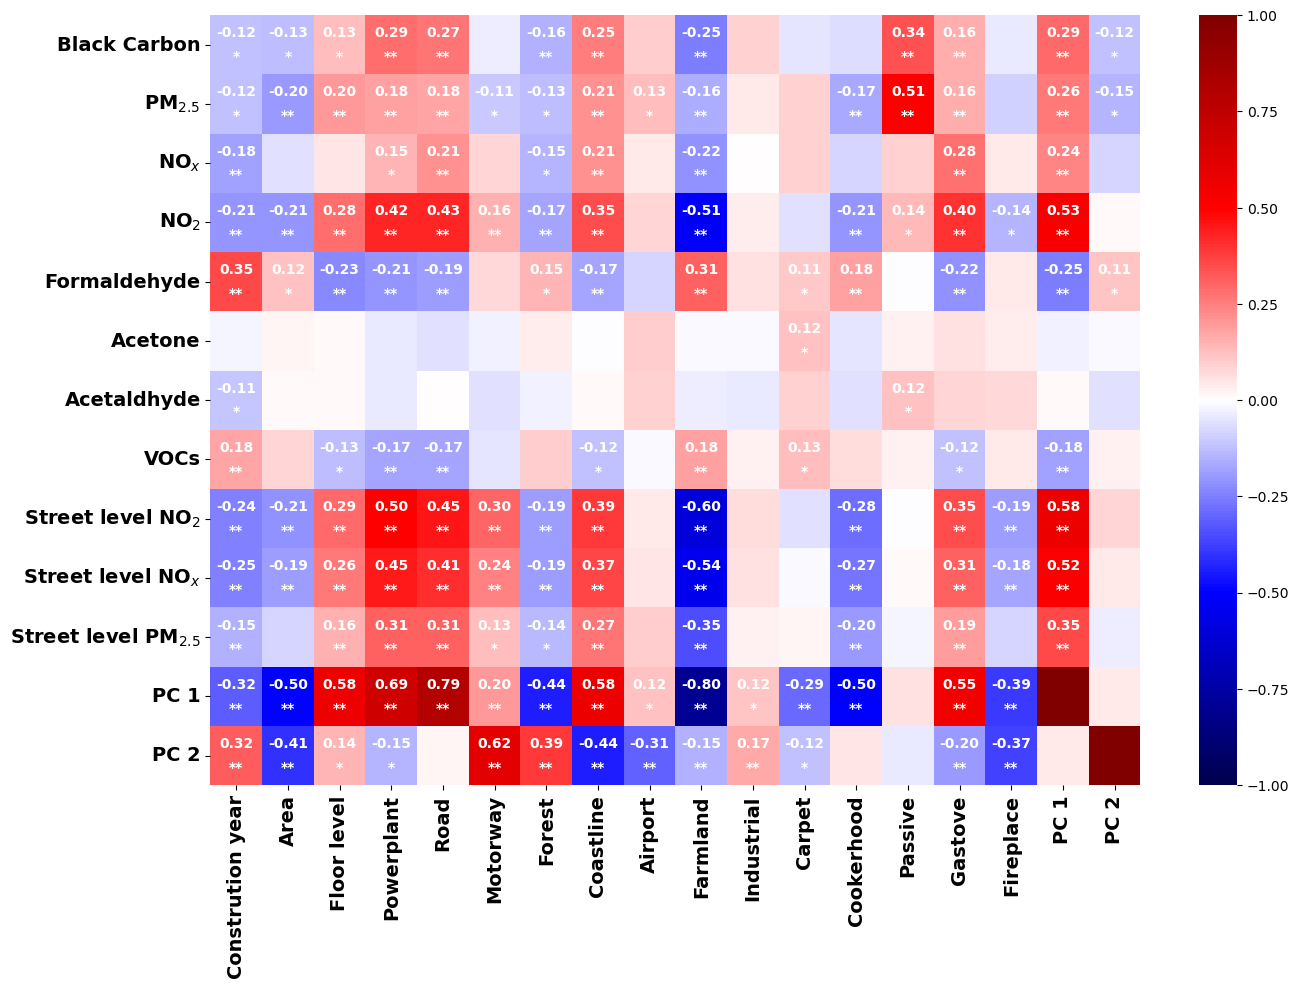

In [13]:
fig,ax=plt.subplots(1,1,figsize=(15,10))
g=sns.heatmap(corr_shape, fmt='g',ax=ax,vmin=-1,vmax=1,cmap = 'seismic')
for i in range(corr_shape.shape[0]):
    for j in range(corr_shape.shape[1]):
        if p_shape.iloc[i, j]<0.05:
            corr = '{:.2f}'.format(corr_shape.iloc[i, j].round(2)),
            pval = p_shape.iloc[i, j].round(1)
            if p_shape.iloc[i, j]*p_shape.shape[0]<0.05:
                ax.text(j+0.5, i+0.3, corr[0], ha='center', va='center', fontsize=10, color='white', fontweight='bold')
                ax.text(j+0.5, i+0.7, "**", ha='center', va='center', fontsize=10, color='white', fontweight='bold')
            else:
                ax.text(j+0.5, i+0.3, corr[0], ha='center', va='center', fontsize=10, color='white', fontweight='bold')
                ax.text(j+0.5, i+0.7, "*", ha='center', va='center', fontsize=10, color='white', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14, fontweight='bold')
                
fig.savefig("../Plots/sources_exposures.png",bbox_inches="tight", dpi=300)

In [14]:
corr_p,p_p=calculate_pvalues(df)
p_particle=p_p.loc[particles,particles]
corr_particle=corr_p.loc[particles,particles]

In [15]:
corr_particle=corr_particle.rename(dict(zip(corr_particle.index,list2)),axis=0)
corr_particle=corr_particle.rename(dict(zip(corr_particle.columns,list2)),axis=1)

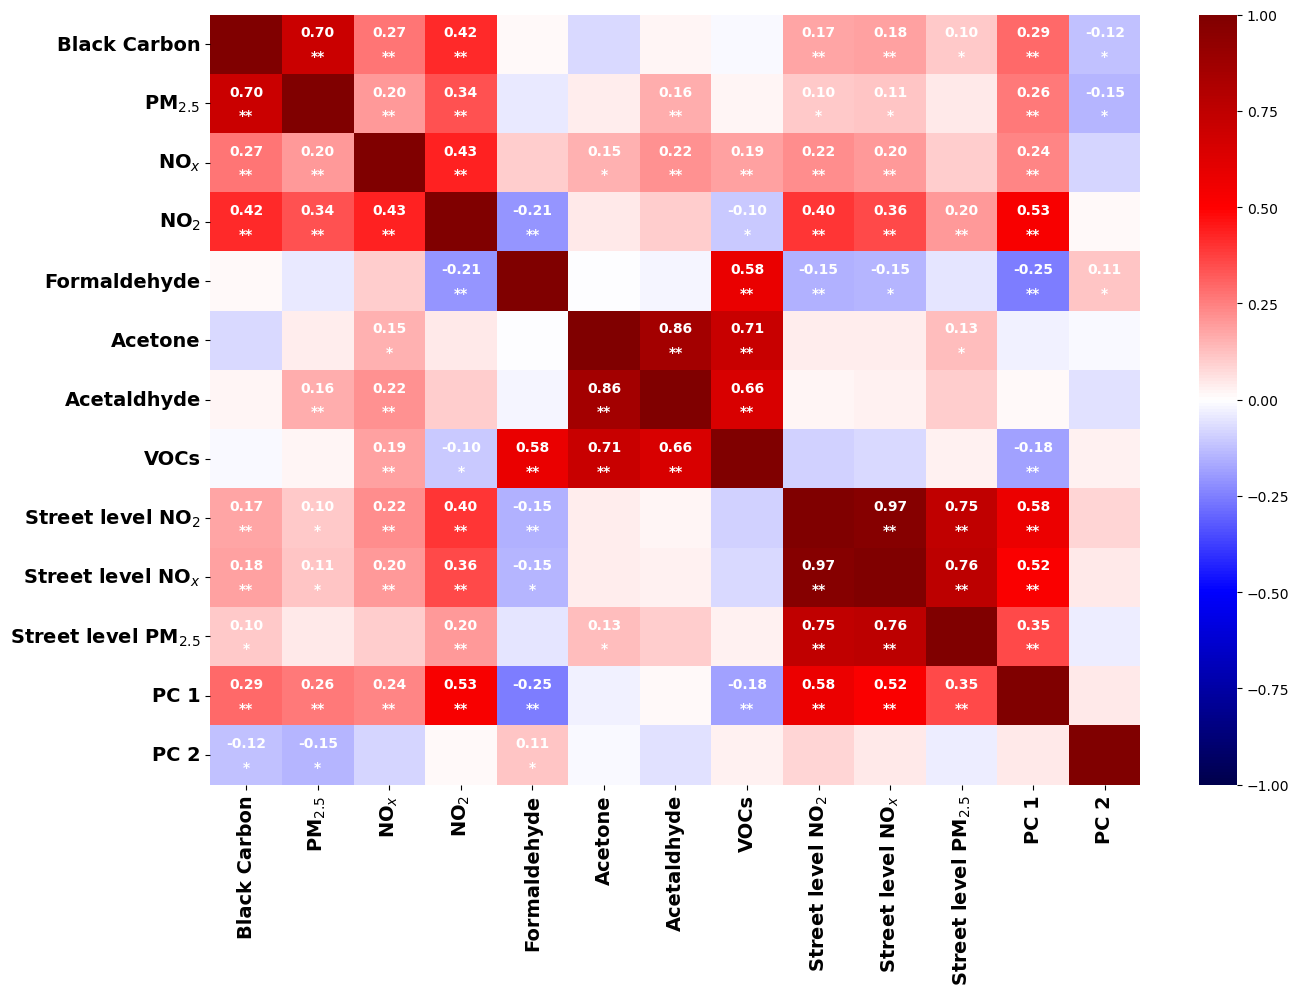

In [16]:
fig,ax=plt.subplots(1,1,figsize=(15,10))
g=sns.heatmap(corr_particle, fmt='g',ax=ax,vmin=-1,vmax=1,cmap = 'seismic')
for i in range(corr_particle.shape[0]):
    for j in range(corr_particle.shape[1]):
        if p_particle.iloc[i, j]<0.05:
            corr = '{:.2f}'.format(corr_particle.iloc[i, j].round(2)),
            pval = p_particle.iloc[i, j].round(1)
            if p_particle.iloc[i, j]*p_particle.shape[0]<0.05:
                ax.text(j+0.5, i+0.3, corr[0], ha='center', va='center', fontsize=10, color='white', fontweight='bold')
                ax.text(j+0.5, i+0.7, "**", ha='center', va='center', fontsize=10, color='white', fontweight='bold')
            else:
                ax.text(j+0.5, i+0.3, corr[0], ha='center', va='center', fontsize=10, color='white', fontweight='bold')
                ax.text(j+0.5, i+0.7, "*", ha='center', va='center', fontsize=10, color='white', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14, fontweight='bold')
                
fig.savefig("../Plots/sources_corr.png",bbox_inches="tight")